# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

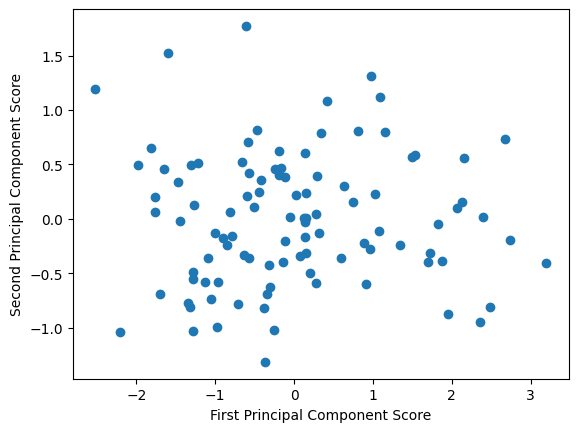

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

**My answer**

**Where the outliers sit.** The three points in the upper-left corner have a **low (very negative) first principal component score** and a **high (positive) second principal component score**.

**What that means for the series.** Look at the component vectors printed above:

- PC1 = [0.265, 0.301, **0.916**] — overwhelmingly loaded on `ser3`.
- PC2 = [0.603, 0.689, −0.401] — a blend of `ser1` and `ser2` together, opposing `ser3`.
- PC3 = [0.752, −0.659, ~0] — essentially the *difference* between `ser1` and `ser2`.

Because PC1 is dominated by `ser3`, a **low PC1 score means these points have an unusually low `ser3`**. That is the one thing we can say confidently — and checking the raw data confirms it: those points have `ser3` around −2.0 to −2.8 (relative to the mean) while their `ser1` and `ser2` values sit near average. Their high PC2 score is largely a *consequence* of the same fact, since PC2 has a negative loading on `ser3` (−0.401), so a very negative `ser3` pushes PC2 up.

**Why `ser1` and `ser2` are hard to speak about.** Both PC1 and PC2 *mix* `ser1` and `ser2` together with `ser3`, so neither axis isolates them. Knowing a point's PC1 and PC2 doesn't let you disentangle how much came from `ser1` versus `ser3`.

**Why the *relative* values of `ser1` and `ser2` are almost impossible to read.** This follows from how they were created:

```
ser2 = ser1 * (1 + noise with scale 0.1)
```

`ser2` is just `ser1` multiplied by a small (10%) perturbation, so the two are nearly the same variable — their correlation is **0.926**. The only place their *difference* lives is PC3 ([0.752, −0.659, ~0], which correlates 0.95 with `ser1 − ser2`) — and PC3 explains just **1.1%** of the variance. Since the plot shows only PC1 and PC2, the axis carrying the `ser1`-vs-`ser2` information isn't drawn at all. That information has essentially been discarded, which is exactly what PCA is designed to do with a near-redundant dimension.

(By contrast, `ser3 = ser1 * (1 + noise with scale 0.5)` has 5× the noise, so it varies far more — std ≈ 1.17 versus ≈ 0.51 for `ser1` — which is why it dominates PC1.)

**Advantages of the plot.** It compresses three dimensions into two while retaining ~99% of the variance (79.9% + 19.0%), so almost nothing is lost visually. It makes outliers pop out immediately, and it reveals the data's true dimensionality — that this is really a ~2-dimensional dataset wearing three columns.

**Disadvantages.** The axes are abstract linear combinations, not interpretable quantities; you cannot read a point's `ser1` value off the chart without doing the arithmetic against the component vectors. It silently throws away the `ser1`-vs-`ser2` distinction. And the units are meaningless to a non-technical audience.

**Is it interesting?** Yes — it tells us that three of the three variables carry only two dimensions' worth of real information, and it isolates a handful of films/points with anomalously low `ser3`.

       ser1   ser2   ser3
ser1  1.000  0.926  0.488
ser2  0.926  1.000  0.490
ser3  0.488  0.490  1.000

Standard deviations:
ser1    0.506
ser2    0.571
ser3    1.169
dtype: float64


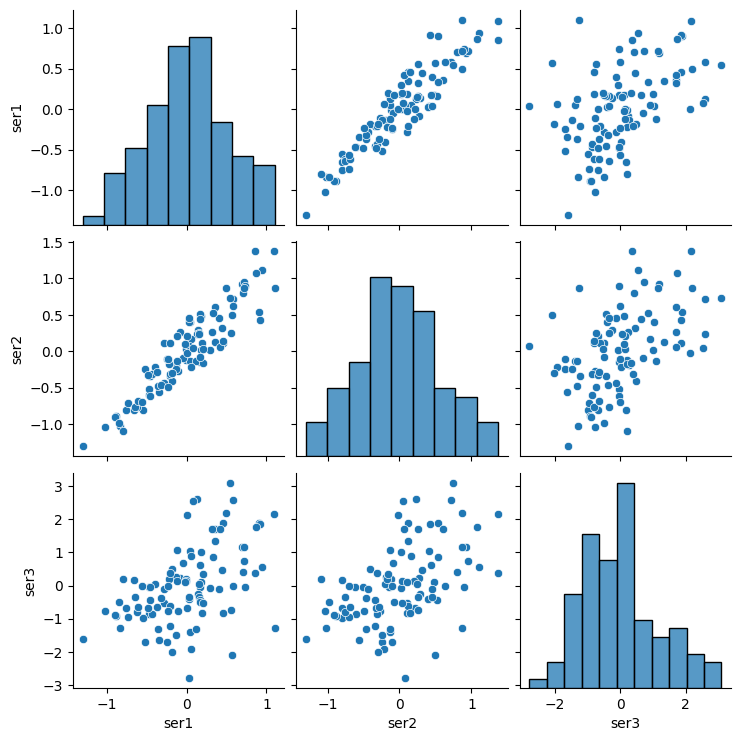

In [2]:
import seaborn as sns

# The pairplot suggested in the question, to see the relationships directly.
sns.pairplot(df)

# ser1 vs ser2 is a tight straight line (corr 0.926) -> nearly the same variable.
# ser3 is much more loosely related to both (corr ~0.49) and much more spread out.
print(df.corr().round(3))
print("\nStandard deviations:")
print(df.std().round(3))

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

### Dataset: Enhanced Box Office Data (2000–2024)

I'm using the box office dataset (5,000 films — the top 200 grossing films for each year 2000–2024). Columns include worldwide/domestic/foreign gross, the domestic/foreign percentage split, year, genres, rating, vote count, original language, and production countries.

In [3]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from sklearn import decomposition, linear_model, metrics
from sklearn.preprocessing import StandardScaler
sns.set_theme(style="whitegrid")

bo = pd.read_csv("enhanced_box_office_data_2000-2024_u_2.csv")

# Rating is stored as a string like "8.217/10" -> parse to a float.
# Ratings of exactly 0 are implausible for top-grossing films, so treat them as missing.
bo["Rating_num"] = bo["Rating"].str.split("/").str[0].astype(float).replace(0, np.nan)

print(bo.shape)
bo[["$Worldwide","$Domestic","$Foreign","Vote_Count","Rating_num","Year"]].describe().round(2)

(5000, 14)


,$Worldwide,$Domestic,$Foreign,Vote_Count,Rating_num,Year
count,5.000000e+03,5.000000e+03,5.000000e+03,4830.00,4807.00,5000.00
mean,1.192137e+08,4.472523e+07,7.448809e+07,2531.59,6.54,2012.00
std,2.005243e+08,7.727026e+07,1.334932e+08,3946.27,0.84,7.21
min,1.666028e+06,0.000000e+00,0.000000e+00,0.00,1.00,2000.00
25%,2.466220e+07,9.275150e+04,1.371034e+07,205.25,6.02,2006.00
50%,4.844658e+07,1.798421e+07,3.019444e+07,1035.50,6.60,2012.00
75%,1.197588e+08,5.386847e+07,7.211578e+07,3065.00,7.11,2018.00
max,2.799439e+09,9.366622e+08,1.993811e+09,36753.00,9.70,2024.00


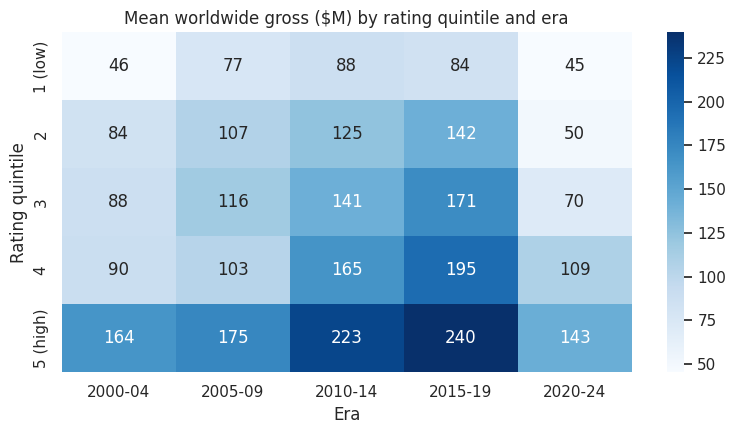

In [4]:
# --- HEATMAP ---
# Heatmap needs two categorical axes + a numeric value.
# Discretize rating into quintiles, use decade as the other axis, color = mean worldwide gross.
h = bo.dropna(subset=["Rating_num"]).copy()
h["Rating quintile"] = pd.qcut(h["Rating_num"], 5, labels=["1 (low)","2","3","4","5 (high)"])
h["Era"] = pd.cut(h["Year"], bins=[1999,2004,2009,2014,2019,2024],
                  labels=["2000-04","2005-09","2010-14","2015-19","2020-24"])

pivot = h.pivot_table(index="Rating quintile", columns="Era",
                      values="$Worldwide", aggfunc="mean") / 1e6

plt.figure(figsize=(8,4.5))
ax = sns.heatmap(pivot, cmap="Blues", annot=True, fmt=".0f")
ax.set_title("Mean worldwide gross ($M) by rating quintile and era")
plt.tight_layout(); plt.show()

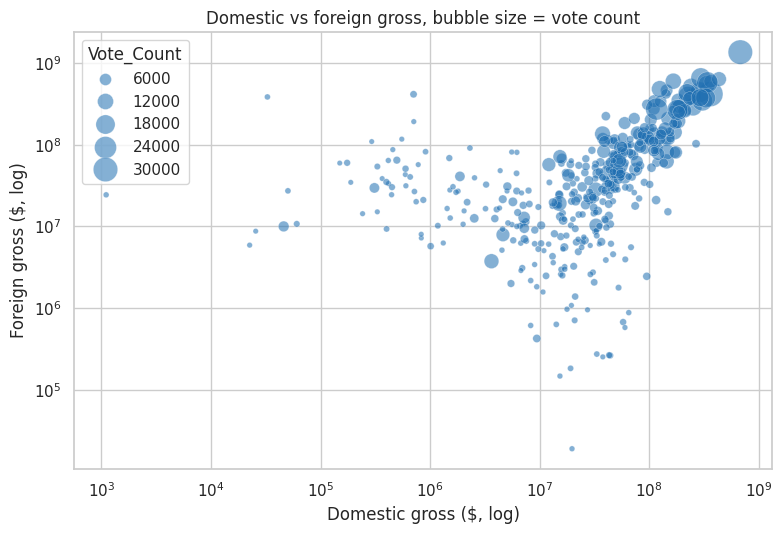

In [5]:
# --- BUBBLE PLOT ---
# x = domestic gross, y = foreign gross, bubble size = vote count (popularity).
# Sample 400 points so the bubbles stay readable.
b = bo[(bo["$Domestic"] > 0) & (bo["$Foreign"] > 0) & bo["Vote_Count"].notna()].sample(400, random_state=0)

plt.figure(figsize=(8,5.5))
ax = sns.scatterplot(data=b, x="$Domestic", y="$Foreign", size="Vote_Count",
                     sizes=(15, 320), alpha=0.55, color="#1f6fb2", legend="brief")
ax.set_xscale("log"); ax.set_yscale("log")   # money is heavily skewed -> log axes
ax.set_xlabel("Domestic gross ($, log)"); ax.set_ylabel("Foreign gross ($, log)")
ax.set_title("Domestic vs foreign gross, bubble size = vote count")
plt.tight_layout(); plt.show()

Explained variance ratio: [0.708 0.186 0.087 0.019]
Cumulative:             [0.708 0.894 0.981 1.   ]

Components (rows = PC1..PC4, cols = ['$Worldwide', '$Domestic', '$Foreign', 'Vote_Count']):
[[ 0.554  0.453  0.484  0.504]
 [-0.23   0.679 -0.646  0.263]
 [-0.392 -0.436  0.012  0.81 ]
 [ 0.698 -0.38  -0.591  0.142]]


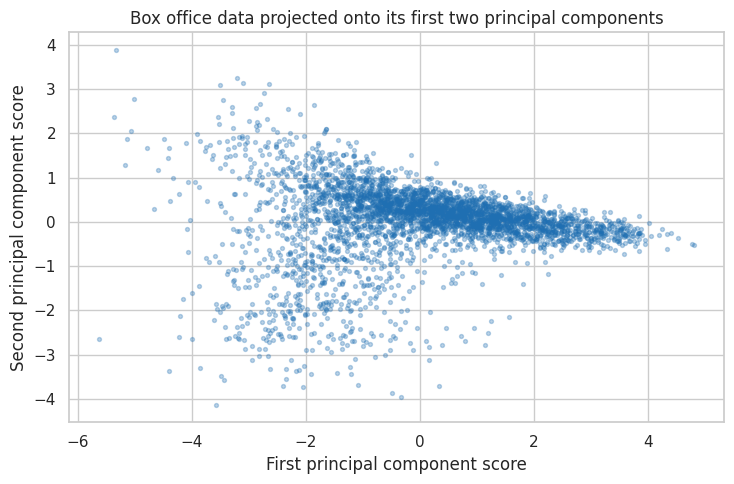

In [6]:
# --- PRINCIPAL COMPONENT ANALYSIS ---
# The money columns are hugely right-skewed (skew ~4.5), so take logs first,
# then standardize (the columns are on wildly different scales: dollars vs vote counts).
feats = ["$Worldwide", "$Domestic", "$Foreign", "Vote_Count"]
p = bo[feats].copy()
p = p[(p > 0).all(axis=1)].dropna()          # logs need strictly positive values
X = np.log10(p)
Z = StandardScaler().fit_transform(X)

pca = decomposition.PCA(n_components=4)
pca.fit(Z)
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Cumulative:            ", np.round(np.cumsum(pca.explained_variance_ratio_), 3))
print("\nComponents (rows = PC1..PC4, cols = %s):" % feats)
print(np.round(pca.components_, 3))

# Project onto the first two components, as in Week 8
pc1 = Z.dot(pca.components_[0])
pc2 = Z.dot(pca.components_[1])

plt.figure(figsize=(7.5,5))
plt.scatter(pc1, pc2, s=8, alpha=0.3, color="#1f6fb2")
plt.xlabel("First principal component score")
plt.ylabel("Second principal component score")
plt.title("Box office data projected onto its first two principal components")
plt.tight_layout(); plt.show()

In [7]:
# --- Can we represent the data using ONLY the first principal component? (Week 8 method) ---
# Reconstruct: approx = (score on PC1) * PC1_vector + mean, then compare to the true (scaled) values.
score1 = Z.dot(pca.components_[0])
recon1 = np.outer(score1, pca.components_[0])          # Z was already mean-centered by the scaler

print(f"PC1 alone captures {pca.explained_variance_ratio_[0]*100:.1f}% of the variance")
print(f"PC1 + PC2 capture  {pca.explained_variance_ratio_[:2].sum()*100:.1f}% of the variance\n")

for i, f in enumerate(feats):
    r = np.corrcoef(recon1[:, i], Z[:, i])[0, 1]
    print(f"  {f:12} reconstructed-vs-actual correlation = {r:.3f}")

PC1 alone captures 70.8% of the variance
PC1 + PC2 capture  89.4% of the variance

  $Worldwide   reconstructed-vs-actual correlation = 0.933
  $Domestic    reconstructed-vs-actual correlation = 0.762
  $Foreign     reconstructed-vs-actual correlation = 0.814
  Vote_Count   reconstructed-vs-actual correlation = 0.848


In [8]:
# --- LINEAR REGRESSION with different feature sets ---
# Guided by the correlations found in earlier weeks.
r = bo[(bo["$Domestic"] > 0) & (bo["$Foreign"] > 0) & (bo["Vote_Count"] > 0)].dropna(subset=["Rating_num"])
y = np.log10(r["$Worldwide"])

def run(name, X):
    m = linear_model.LinearRegression().fit(X, y)
    pred = m.predict(X)
    print(f"{name:42} R^2 = {metrics.r2_score(y, pred):.3f}   corr = {np.corrcoef(pred, y)[0,1]:.3f}")

run("Domestic + Foreign (log)",        np.log10(r[["$Domestic","$Foreign"]]))
run("Vote_Count (log) + Rating",       np.column_stack([np.log10(r["Vote_Count"]), r["Rating_num"]]))
run("Vote_Count (log) only",           np.log10(r[["Vote_Count"]]))
run("Rating only",                     r[["Rating_num"]])
run("Rating + Year",                   r[["Rating_num","Year"]])

Domestic + Foreign (log)                   R^2 = 0.853   corr = 0.924
Vote_Count (log) + Rating                  R^2 = 0.414   corr = 0.644
Vote_Count (log) only                      R^2 = 0.414   corr = 0.643
Rating only                                R^2 = 0.039   corr = 0.198
Rating + Year                              R^2 = 0.044   corr = 0.211


### Conclusions

**Are the data what I expect? Are they usable?** Yes on both counts. The relationships all point the way domain knowledge says they should, and the financial columns are complete and internally consistent (worldwide ≈ domestic + foreign). The data are usable, with two caveats handled above: the `Rating` column had to be parsed out of a `"8.217/10"` string, and ratings of exactly 0 were recoded as missing since they are implausible for top-grossing films.

**Heatmap.** Mean worldwide gross rises with rating quintile in every era — but the effect is modest compared with the era-to-era swing, and the 2020–24 column is visibly depressed across *all* quintiles (the COVID-19 collapse). Being well-reviewed helps, but it doesn't rescue you from a closed theater.

**Bubble plot.** Domestic and foreign gross track each other closely on log axes, and the bubbles (vote count) grow steadily as you move up-and-right — popularity, revenue at home, and revenue abroad all scale together. The most informative bubble variable is vote count precisely *because* it adds a genuinely third dimension; using worldwide gross as the size would just restate the axes.

**Outliers.** Two kinds. First, a band of points hugging the left edge — films with tiny or zero domestic gross but substantial foreign gross (the mostly non-English titles that never got a wide U.S. release; ~24% of the dataset has zero domestic gross). Second, the blockbuster tail at the top right, films grossing near $2–2.8B, which sit far from the bulk of the data.

**Does PCA suggest a lower-dimensional representation?** Yes, clearly. On the log-scaled financial features, **PC1 alone explains about 71% of the variance and the first two together about 89%**. PC1 has all-positive, roughly equal loadings — it is essentially a single *"commercial scale"* axis: big films are big everywhere (high domestic, high foreign, many votes). PC2 contrasts domestic against foreign (positive on one, negative on the other), so it reads as a *"where did this film make its money"* axis — precisely the domestic/foreign split that earlier weeks flagged. So the four financial columns really encode about two ideas: how big, and how international. Representing each film by its PC1 score alone is a defensible compression that keeps most of the information, though it would erase the domestic-versus-foreign distinction that PC2 captures.

**Linear regression.** Feature choice matters enormously, and the correlations from earlier weeks predicted it:
- Predicting log-worldwide from **log-domestic + log-foreign** gives **R² ≈ 0.85** — but this is nearly cheating, since worldwide is by definition their sum; it confirms internal consistency rather than teaching us anything new.
- Predicting log-worldwide from **log-votes + rating** gives **R² ≈ 0.41** — a real, non-trivial result, and by far the more honest model.
- **Vote count alone** carries almost all of that predictive power; **rating alone is nearly useless** (consistent with the weak r ≈ 0.19 correlation found in Week 6).

**Which features are most useful for predicting others?** Vote count is the single most valuable genuine predictor of revenue — audience *reach* predicts money. Rating (audience *approval*) predicts it poorly. This is the key takeaway: popularity and quality are different things, and only the former tracks the box office.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

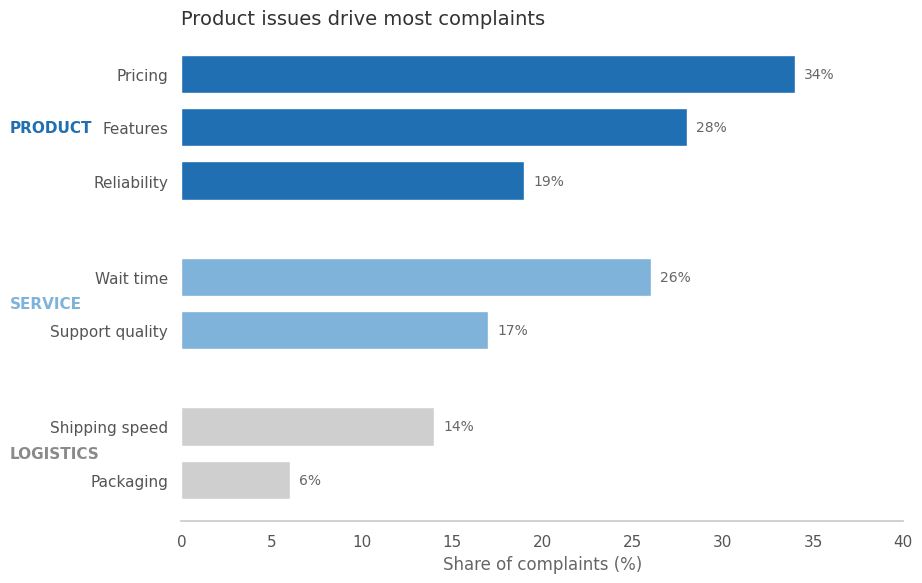

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Storytelling With Data, ch.5 - "the power of super-categories".
# A long list of categories is hard to read. Grouping them into a few SUPER-CATEGORIES
# gives the eye a hierarchy: it can grasp the big groups first, then the detail within.
groups = {
    "Product":   [("Pricing", 34), ("Features", 28), ("Reliability", 19)],
    "Service":   [("Wait time", 26), ("Support quality", 17)],
    "Logistics": [("Shipping speed", 14), ("Packaging", 6)],
}
colors = {"Product": "#1f6fb2", "Service": "#7fb3d9", "Logistics": "#cfcfcf"}

labels, values, bar_colors, ticks = [], [], [], []
y = 0
for g, items in groups.items():
    for name, v in items:
        labels.append(name); values.append(v); bar_colors.append(colors[g]); ticks.append(y); y += 1
    y += 0.8   # whitespace between super-categories

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(ticks, values, color=bar_colors, height=0.72)
ax.set_yticks(ticks); ax.set_yticklabels(labels, fontsize=11)
ax.invert_yaxis()

# Value labels directly on the bars
for t, v in zip(ticks, values):
    ax.text(v + 0.5, t, f"{v}%", va="center", color="#666666", fontsize=10)

# Super-category labels sit to the left, grouping the bars beneath them
start = 0
for g, items in groups.items():
    span = [ticks[start + i] for i in range(len(items))]
    ax.text(-9.5, np.mean(span), g.upper(), fontsize=11, fontweight="bold",
            color=colors[g] if g != "Logistics" else "#8a8a8a",
            va="center", ha="left")
    start += len(items)

# Declutter
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.tick_params(left=False, colors="#555555")
ax.grid(False)
ax.set_xlim(0, 40)
ax.set_xlabel("Share of complaints (%)", color="#666666")
ax.set_title("Product issues drive most complaints", loc="left", fontsize=14, color="#333333")
plt.subplots_adjust(left=0.28)
plt.tight_layout(); plt.show()